In [28]:
import pandas as pd

url = 'train.csv'

df = pd.read_csv(url)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [29]:
# 🌟 Exercise 1: Duplicate Detection and Removal

# verfication des lignes dupliquées

print(df.duplicated().sum())

# nombre de lignes avant la suppression
print(len(df))

#supprimer les lignes dupliquées
df = df.drop_duplicates()


# nombre de lignes après la suppression
print(len(df))

0
891
891


In [30]:
# 🌟 Exercise 2: Handling Missing Values
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='mean')

# columns in the Titanic dataset with missing values
print(df.isnull().sum())
print("----------------------------------------------------------------------------")
print(df.shape)
print("----------------------------------------------------------------------------")
print(df.dtypes)
# supprimer la colonne cabin comme bcp de lignes contiennent des nulls
df = df.drop(columns=['Cabin'])
# imputer par valeur fréquente pour colonne de type object
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
# imputer par la moyenne
df['Age'] = imputer.fit_transform(df[['Age']])
print("----------------------------------------------------------------------------")
print("APRES TRANSFORMATION ")
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
----------------------------------------------------------------------------
(891, 12)
----------------------------------------------------------------------------
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object
----------------------------------------------------------------------------
APRES TRANSFORMATION 
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [ ]:
# 🌟 Exercise 3: Feature Engineering

df['Family_Size'] = df['SibSp'] + df['Parch']

df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

df = pd.get_dummies(df, columns=['Title', 'Sex', 'Embarked'])

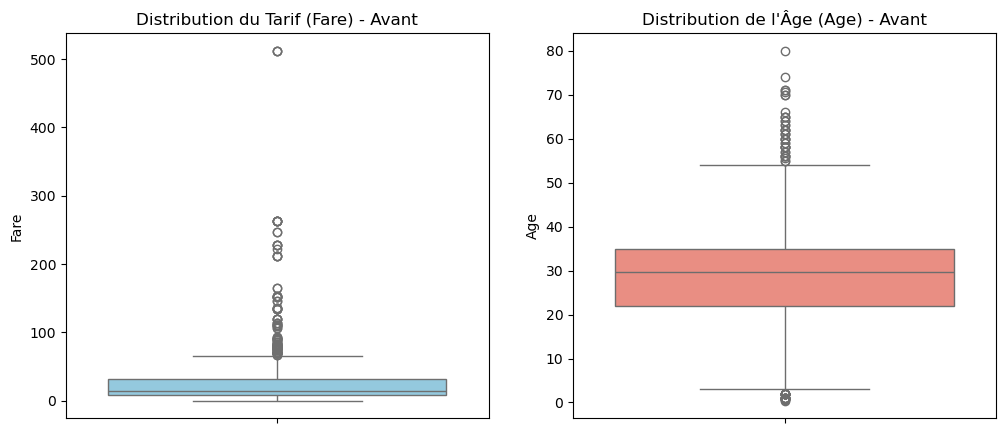

Borne max acceptée pour Fare selon l'IQR : 65.63
Nombre d'outliers détectés pour Fare : 116


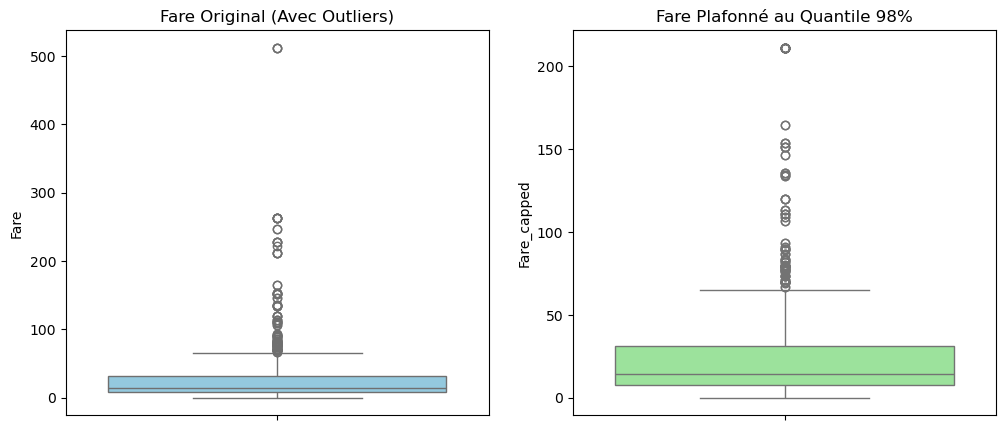

Statistiques AVANT traitement :
max     512.329200
mean     32.204208
std      49.693429
Name: Fare, dtype: float64

Statistiques APRÈS traitement (Capping) :
max     211.337500
mean     30.678483
std      39.904946
Name: Fare_capped, dtype: float64


In [34]:
# 🌟 Exercise 4: Outlier Detection and Handling
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
#print(df.dtypes)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=df, y='Fare', ax=axes[0], color='skyblue')
axes[0].set_title("Distribution du Tarif (Fare) - Avant")

sns.boxplot(data=df, y='Age', ax=axes[1], color='salmon')
axes[1].set_title("Distribution de l'Âge (Age) - Avant")

plt.show()


# Calcul des quartiles
Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)
IQR = Q3 - Q1

# Définition des bornes limites
borne_inferieure = Q1 - 1.5 * IQR
borne_superieure = Q3 + 1.5 * IQR

print(f"Borne max acceptée pour Fare selon l'IQR : {borne_superieure:.2f}")

# Détection des outliers
outliers_fare = df[(df['Fare'] < borne_inferieure) | (df['Fare'] > borne_superieure)]
print(f"Nombre d'outliers détectés pour Fare : {len(outliers_fare)}")

# strategy A

# On trouve la valeur au quantile 98%
seuil_max_fare = df['Fare'].quantile(0.98)

# On applique le plafonnement : si Fare > seuil, on le remplace par le seuil
df['Fare_capped'] = df['Fare'].clip(upper=seuil_max_fare)

# strategy b : transformation logarithmique
# On utilise log1p (log de x + 1) pour éviter le problème si un tarif vaut 0
df['Fare_log'] = np.log1p(df['Fare'])


# Supprimons les lignes où l'âge dépasse la borne supérieure IQR de l'âge
Q1_age = df['Age'].quantile(0.25)
Q3_age = df['Age'].quantile(0.75)
IQR_age = Q3_age - Q1_age
borne_sup_age = Q3_age + 1.5 * IQR_age

# On ne garde que les lignes en dessous de la borne
df_clean = df[df['Age'] <= borne_sup_age].copy()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=df, y='Fare', ax=axes[0], color='skyblue')
axes[0].set_title("Fare Original (Avec Outliers)")

sns.boxplot(data=df, y='Fare_capped', ax=axes[1], color='lightgreen')
axes[1].set_title("Fare Plafonné au Quantile 98%")

plt.show()

# Comparaison des statistiques descriptives
print("Statistiques AVANT traitement :")
print(df['Fare'].describe()[['max', 'mean', 'std']])
print("\nStatistiques APRÈS traitement (Capping) :")
print(df['Fare_capped'].describe()[['max', 'mean', 'std']])

In [35]:
#🌟 Exercise 5: Data Standardization and Normalization

from sklearn.preprocessing import StandardScaler, MinMaxScaler

# 1. Initialisation des outils de mise à l'échelle
scaler_standard = StandardScaler()
scaler_minmax = MinMaxScaler()

# 2. Application de StandardScaler sur la colonne 'Age'
# (Rappel : les doubles crochets [['Age']] sont obligatoires pour scikit-learn)
df['Age_scaled'] = scaler_standard.fit_transform(df[['Age']])

# 3. Application de MinMaxScaler sur la colonne 'Fare_capped'
df['Fare_scaled'] = scaler_minmax.fit_transform(df[['Fare_capped']])

print("Mise à l'échelle terminée avec succès !")

print("--- VÉRIFICATION DE L'ÂGE (StandardScaler) ---")
print(df['Age_scaled'].describe()[['mean', 'std', 'min', 'max']])
# Tu vas remarquer que la moyenne (mean) est extrêmement proche de 0 (ex: -1.6e-16) et l'écart-type (std) vaut 1.

print("\n--- VÉRIFICATION DU TARIF (MinMaxScaler) ---")
print(df['Fare_scaled'].describe()[['min', 'max', 'mean']])
# Tu vas remarquer que le min est pile à 0.0 et le max est pile à 1.0.

Mise à l'échelle terminée avec succès !
--- VÉRIFICATION DE L'ÂGE (StandardScaler) ---
mean    2.232906e-16
std     1.000562e+00
min    -2.253155e+00
max     3.870872e+00
Name: Age_scaled, dtype: float64

--- VÉRIFICATION DU TARIF (MinMaxScaler) ---
min     0.000000
max     1.000000
mean    0.145163
Name: Fare_scaled, dtype: float64


In [38]:
# 🌟 Exercise 6: Feature Encoding

# 1. Sélection des colonnes catégorielles à encoder
colonnes_a_encoder = ['Sex', 'Embarked']

# 2. Application du One-Hot Encoding
# drop_first=True est une astuce statistique pour éviter la redondance (ex: si 'male' vaut 0, alors c'est forcément une 'female')
df_encoded = pd.get_dummies(df, columns=colonnes_a_encoder, drop_first=True, dtype=int)

print("Encodage terminé !")

print("\n--- LISTE DES COLONNES FINALES ---")
print(df_encoded.dtypes)

Encodage terminé !

--- LISTE DES COLONNES FINALES ---
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Fare_capped    float64
Fare_log       float64
Age_scaled     float64
Fare_scaled    float64
Sex_male         int64
Embarked_Q       int64
Embarked_S       int64
dtype: object


In [39]:
# e7

# 1. Définition des frontières des tranches (bins) et de leurs étiquettes (labels)
limites_age = [0, 12, 18, 60, 100]
categories_age = ['Child', 'Teen', 'Adult', 'Senior']

# 2. Création de la colonne textuelle 'Age_Group'
df['Age_Group'] = pd.cut(df['Age'], bins=limites_age, labels=categories_age, include_lowest=True)

# Petite vérification rapide pour voir la répartition
print(df['Age_Group'].value_counts())

# 3. Encodage avec pd.get_dummies()
# On utilise drop_first=True pour éviter le piège de la colinéarité en statistiques
df_final = pd.get_dummies(df, columns=['Age_Group'], drop_first=True, dtype=int)

print("\nEncodage des tranches d'âge réussi !")

# Affichage des nouvelles colonnes pour vérifier le résultat
colonnes_age = [col for col in df_final.columns if 'Age_Group' in col]
print("\n--- NOUVELLES COLONNES CRÉÉES ---")
print(df_final[colonnes_age].head())

Age_Group
Adult     730
Teen       70
Child      69
Senior     22
Name: count, dtype: int64

Encodage des tranches d'âge réussi !

--- NOUVELLES COLONNES CRÉÉES ---
   Age_Group_Teen  Age_Group_Adult  Age_Group_Senior
0               0                1                 0
1               0                1                 0
2               0                1                 0
3               0                1                 0
4               0                1                 0
